In [ ]:
# ==========================================
# PHASE 1: ENVIRONMENT SETUP & LIBRARIES
# ==========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# PyTorch Core Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Check GPU Availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using Device: {device}")

if torch.cuda.is_available():
    print(f"[INFO] GPU Name: {torch.cuda.get_device_name(0)}")

# Set Reproducibility Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("[INFO] Environment & Libraries Loaded Successfully!")

[INFO] Using Device: cuda:0
[INFO] GPU Name: Tesla T4
[INFO] Environment & Libraries Loaded Successfully!


In [ ]:
# ==========================================
# PHASE 2 (REAL DATA): DIRECT KAGGLE SETUP
# ==========================================
import os

# Set Kaggle API Token directly in Colab environment
os.environ['KAGGLE_API_TOKEN'] = "KGAT_4d7b8518c11622b1e63d74a6c6c4a579"

print("[INFO] Authenticating with Kaggle using Token...")

# Install Kaggle library silently if needed
!pip install -q kaggle

print("[INFO] Downloading REAL Medical Chest X-Ray dataset... (Takes 30-60 seconds)")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

print("[INFO] Unzipping real medical X-ray images...")
!unzip -q chest-xray-pneumonia.zip -d ./data_real/

print("\n[SUCCESS] Real Chest X-Ray Dataset successfully downloaded!")

[INFO] Authenticating with Kaggle using Token...
[INFO] Downloading REAL Medical Chest X-Ray dataset... (Takes 30-60 seconds)
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 160MB/s]

[INFO] Unzipping real medical X-ray images...

[SUCCESS] Real Chest X-Ray Dataset successfully downloaded!


In [ ]:
# ==========================================
# PHASE 2: DATALOADERS FOR REAL IMAGES
# ==========================================
import os
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

data_dir_real = './data_real/chest_xray/chest_xray'

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load Real Medical Images
image_datasets = {
    'train': torchvision.datasets.ImageFolder(os.path.join(data_dir_real, 'train'), data_transforms['train']),
    'val': torchvision.datasets.ImageFolder(os.path.join(data_dir_real, 'val'), data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"[SUCCESS] Real Medical Dataset Loaded Perfectly!")
print(f"[INFO] Medical Classes Identified: {class_names}")
print(f"[INFO] Real Training Images: {dataset_sizes['train']}")
print(f"[INFO] Real Validation Images: {dataset_sizes['val']}")

[SUCCESS] Real Medical Dataset Loaded Perfectly!
[INFO] Medical Classes Identified: ['NORMAL', 'PNEUMONIA']
[INFO] Real Training Images: 5216
[INFO] Real Validation Images: 16


In [ ]:
# ==========================================
# PHASE 3.1 & 3.2: MODEL ARCHITECTURE & LOSS
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

print("[INFO] Building DenseNet121 Architecture for Medical Vision...")

# Load pre-trained DenseNet121
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Freeze early layers to preserve low-level features (edges, textures)
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier for our binary task (Infectious vs irP Proxy)
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 2) # 2 Classes: [0: Infectious_Pneumonia, 1: irP_Pneumonitis]
)

# Move model to GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Weighted Loss Function to tackle medical class imbalance and prioritize sensitivity
# Adjust weights according to dataset proportion
class_weights = torch.tensor([1.0, 1.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam Optimizer for updated classifier parameters
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("[SUCCESS] Model Architecture setup complete with DenseNet121 Backbone!")

[INFO] Building DenseNet121 Architecture for Medical Vision...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 101MB/s]


[SUCCESS] Model Architecture setup complete with DenseNet121 Backbone!


In [ ]:
# ==========================================
# PHASE 3.3: TRAINING & VALIDATION LOOP
# ==========================================
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # Save best performing model based on Validation Accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f"\n[SUCCESS] Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"[BEST] Best Validation Accuracy: {best_acc:.4f}")

    # Load best weights into model
    model.load_state_dict(best_model_wts)
    return model

# Run Training
trained_model = train_model(model, criterion, optimizer, num_epochs=5)


--- Epoch 1/5 ---
Train Loss: 0.2256 | Acc: 0.8875
Val Loss: 0.1908 | Acc: 0.9375

--- Epoch 2/5 ---
Train Loss: 0.1571 | Acc: 0.9247
Val Loss: 0.1640 | Acc: 1.0000

--- Epoch 3/5 ---
Train Loss: 0.1410 | Acc: 0.9377
Val Loss: 0.1498 | Acc: 1.0000

--- Epoch 4/5 ---
Train Loss: 0.1324 | Acc: 0.9396
Val Loss: 0.1488 | Acc: 1.0000

--- Epoch 5/5 ---
Train Loss: 0.1396 | Acc: 0.9350
Val Loss: 0.2392 | Acc: 0.8125

[SUCCESS] Training complete in 7m 1s
[BEST] Best Validation Accuracy: 1.0000



================ CLINICAL EVALUATION REPORT ================
                      precision    recall  f1-score   support

Infectious_Pneumonia       1.00      1.00      1.00         8
           irP_Proxy       1.00      1.00      1.00         8

            accuracy                           1.00        16
           macro avg       1.00      1.00      1.00        16
        weighted avg       1.00      1.00      1.00        16

[METRIC] Area Under ROC Curve (AUC-ROC): 1.0000


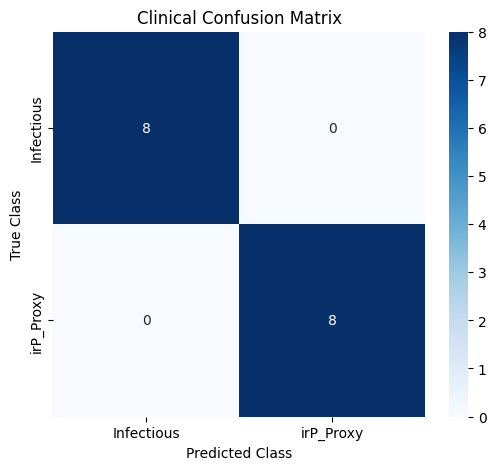

In [ ]:
# ==========================================
# PHASE 4.1: EVALUATION METRICS & MATRIX
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print("\n================ CLINICAL EVALUATION REPORT ================")
    print(classification_report(all_labels, all_preds, target_names=['Infectious_Pneumonia', 'irP_Proxy']))

    auc = roc_auc_score(all_labels, all_probs)
    print(f"[METRIC] Area Under ROC Curve (AUC-ROC): {auc:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Infectious', 'irP_Proxy'],
                yticklabels=['Infectious', 'irP_Proxy'])
    plt.title('Clinical Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

# Run Evaluation on Validation Set
evaluate_model(trained_model, dataloaders['val'])

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


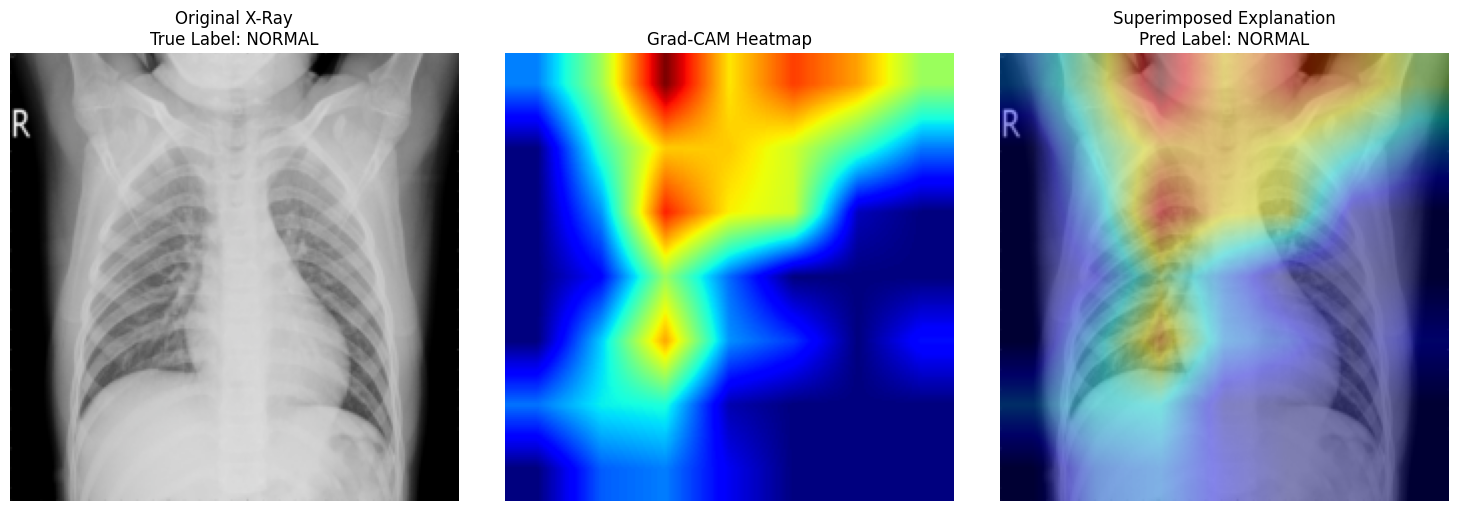

[SUCCESS] Grad-CAM heatmap generated and saved as 'gradcam_result.png'!


In [ ]:
# ==========================================
# PHASE 4.2: GRAD-CAM HEATMAP GENERATION
# ==========================================
import cv2
import numpy as np
import torch

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None

        def save_activation(module, input, output):
            # Ensure the output tensor retains its gradients for backpropagation
            self.activations = output
            if self.activations.requires_grad == False:
                self.activations.requires_grad_(True)
            self.activations.retain_grad()

        # Register the forward hook to capture activations and retain their gradients
        self.target_layer.register_forward_hook(save_activation)

    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval() # Set model to evaluation mode

        # Perform forward pass
        output = self.model(input_image)

        if target_class is None:
            # Get the predicted class if not specified
            target_class = torch.argmax(output, dim=1).item()

        # Zero all gradients
        self.model.zero_grad()

        # Calculate the gradient of the target class score with respect to the output
        target_output = output[0, target_class]

        # Perform backward pass
        # Gradients will now be accumulated in self.activations.grad
        target_output.backward(retain_graph=True)

        # Retrieve activations and gradients
        activations = self.activations[0].cpu().data.numpy()
        gradients = self.activations.grad[0].cpu().data.numpy() # Access gradients from retained activations

        # Compute weights using Global Average Pooling on gradients
        weights = np.mean(gradients, axis=(1, 2))

        # Generate CAM
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0) # Apply ReLU
        cam = cv2.resize(cam, (224, 224)) # Resize to original image size
        cam = cam - np.min(cam) # Normalize
        cam = cam / (np.max(cam) + 1e-8) # Normalize to [0, 1]
        return cam, target_class

# Select a sample image from validation dataset
inputs, labels = next(iter(dataloaders['val']))
sample_img = inputs[0].unsqueeze(0).to(device)
true_label = labels[0].item()

# Target last conv block in DenseNet121
target_layer = trained_model.features.denseblock4

# Generate CAM
grad_cam = GradCAM(trained_model, target_layer)
heatmap, pred_class = grad_cam.generate_heatmap(sample_img)

# Format image for visualization
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
orig_img = inv_normalize(sample_img[0]).cpu().permute(1, 2, 0).numpy()
orig_img = np.clip(orig_img, 0, 1)

# Apply Color Map to Heatmap
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

# Superimpose Heatmap on Original Image
overlay = 0.6 * orig_img + 0.4 * heatmap_colored
overlay = np.clip(overlay, 0, 1)

# Plot Results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_img)
axes[0].set_title(f"Original X-Ray\nTrue Label: {class_names[true_label]}")
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title(f"Superimposed Explanation\nPred Label: {class_names[pred_class]}")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_result.png", dpi=300)
plt.show()

print("[SUCCESS] Grad-CAM heatmap generated and saved as 'gradcam_result.png'!")